# sprint 2. pre-processamento e modelo 2

projeto: infant dysbiosis predictor  
sprint: 14/4  

etapas:
1. encoding das variaveis categoricas
2. treinamento do Random Forest para classificacao de cluster DMM (C1/C2/C3)
3. avaliacao com F1-score ponderado e matriz de confusao
4. analise dos clusters mais dificeis de separar

## 0. imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.max_columns', 30)

## 1. carregar datasets limpos

> **pre-requisito:** executar `sprint1.1_inspecao_dados.ipynb` para gerar os arquivos em `data/processed/`.

In [9]:
df_m2_raw = pd.read_csv('../data/processed/model2_cluster_dataset.csv')
df_m1_raw = pd.read_csv('../data/processed/model1_outcome_dataset.csv')

print(f'modelo 2 (cluster)  : {df_m2_raw.shape}')
print(f'modelo 1 (desfecho) : {df_m1_raw.shape}')
print()
df_m2_raw.head(3)

modelo 2 (cluster)  : (412, 11)
modelo 1 (desfecho) : (208, 12)



,sample_id,birth_mode,feeding_mode,mother_antibiotics,baby_sex,baby_ethnicity,baby_race,Normed Age at Collection (days),amr_gene_sum_abundance,vf_sum_abundance,dmm_clusters_taxa
0,sample_1,Vaginal,Mixed,No,Female,Not Hispanic or Latino,White,46,0.003154,0.001116,C2
1,sample_2,Vaginal,Breast,No,Female,Not Hispanic or Latino,White,53,0.004510,0.013960,C3
2,sample_3,Vaginal,Breast,No,Male,Not Hispanic or Latino,White,81,0.002067,0.000599,C2


## 2. encoding das variaveis categoricas

estrategia por variavel:

| variavel | cardinalidade | estrategia |
|---|---|---|
| `birth_mode` | 2 | mapa binario: Vaginal→0, C-section→1 |
| `mother_antibiotics` | 2 | mapa binario: No→0, Yes→1 |
| `baby_sex` | 2 | mapa binario: Female→0, Male→1 |
| `baby_ethnicity` | 2 | mapa binario: Not Hispanic or Latino→0, Hispanic or Latino→1 |
| `baby_race` | 4 (desbalanceada) | agrupar White→0, demais→1 (Other); grupos minoritarios < 20 amostras |
| `feeding_mode` | 3 | one-hot encoding (3 dummies, sem drop — arvore nao sofre com multicolinearidade) |

variaveis numericas (`Normed Age at Collection (days)`, `amr_gene_sum_abundance`, `vf_sum_abundance`) recebem `StandardScaler` — irrelevante para Random Forest mas necessario para comparacoes futuras com modelos lineares.

### 2.1 mapeamentos binarios

In [10]:
BINARY_MAPS = {
    'birth_mode'        : {'Vaginal': 0, 'C-Section': 1},
    'mother_antibiotics': {'No': 0, 'Yes': 1},
    'baby_sex'          : {'Female': 0, 'Male': 1},
    'baby_ethnicity'    : {'Not Hispanic or Latino': 0, 'Hispanic or Latino': 1},
}

def apply_binary_maps(df):
    df = df.copy()
    for col, mapping in BINARY_MAPS.items():
        df[col] = df[col].map(mapping)
    # baby_race: White=0, qualquer outra=1
    df['baby_race'] = (df['baby_race'] != 'White').astype(int)
    return df

# verificar antes
print('valores unicos ANTES do encoding:')
for col in list(BINARY_MAPS) + ['baby_race']:
    print(f'  {col}: {sorted(df_m2_raw[col].unique())}')

valores unicos ANTES do encoding:
  birth_mode: ['C-Section', 'Vaginal']
  mother_antibiotics: ['No', 'Yes']
  baby_sex: ['Female', 'Male']
  baby_ethnicity: ['Hispanic or Latino', 'Not Hispanic or Latino']
  baby_race: ['American Indian or Alaska Native', 'Asian', 'Black or African American', 'White']


### 2.2 one-hot encoding: feeding_mode

In [11]:
def apply_ohe(df):
    df = df.copy()
    ohe = pd.get_dummies(df['feeding_mode'], prefix='feeding').astype(int)
    df = pd.concat([df.drop(columns='feeding_mode'), ohe], axis=1)
    return df

print('categorias de feeding_mode e suas dummies:')
print(df_m2_raw['feeding_mode'].value_counts())
print()
print('colunas geradas:', [f'feeding_{c}' for c in df_m2_raw['feeding_mode'].unique()])

categorias de feeding_mode e suas dummies:
feeding_mode
Breast     222
Mixed      138
Formula     52
Name: count, dtype: int64

colunas geradas: ['feeding_Mixed', 'feeding_Breast', 'feeding_Formula']


### 2.3 scaling das variaveis numericas

In [12]:
NUM_COLS = [
    'Normed Age at Collection (days)',
    'amr_gene_sum_abundance',
    'vf_sum_abundance',
]

def apply_scaling(df, scaler=None, fit=True):
    df = df.copy()
    if scaler is None:
        scaler = StandardScaler()
    if fit:
        df[NUM_COLS] = scaler.fit_transform(df[NUM_COLS])
    else:
        df[NUM_COLS] = scaler.transform(df[NUM_COLS])
    return df, scaler

print('estatisticas ANTES do scaling:')
print(df_m2_raw[NUM_COLS].describe().round(4))

estatisticas ANTES do scaling:
       Normed Age at Collection (days)  amr_gene_sum_abundance  \
count                         412.0000                412.0000   
mean                           54.3447                  0.0032   
std                            14.1510                  0.0011   
min                             6.0000                  0.0012   
25%                            44.0000                  0.0023   
50%                            53.0000                  0.0031   
75%                            61.0000                  0.0040   
max                           155.0000                  0.0074   

       vf_sum_abundance  
count          412.0000  
mean             0.0033  
std              0.0045  
min              0.0000  
25%              0.0005  
50%              0.0014  
75%              0.0044  
max              0.0324  


### 2.4 pipeline completo

In [13]:
def preprocess(df, scaler=None, fit=True):
    df = apply_binary_maps(df)
    df = apply_ohe(df)
    df, scaler = apply_scaling(df, scaler=scaler, fit=fit)
    return df, scaler

# ── modelo 2
df_m2, scaler_m2 = preprocess(df_m2_raw)

# ── modelo 1 (mesmo scaler do m2 nao faz sentido — dados diferentes; fit separado)
df_m1, scaler_m1 = preprocess(df_m1_raw)

print('colunas apos encoding (modelo 2):')
feature_cols_m2 = [c for c in df_m2.columns if c not in ('sample_id', 'dmm_clusters_taxa')]
for i, c in enumerate(feature_cols_m2, 1):
    print(f'  {i:>2}. {c}')
print(f'\ntotal: {len(feature_cols_m2)} features')

colunas apos encoding (modelo 2):
   1. birth_mode
   2. mother_antibiotics
   3. baby_sex
   4. baby_ethnicity
   5. baby_race
   6. Normed Age at Collection (days)
   7. amr_gene_sum_abundance
   8. vf_sum_abundance
   9. feeding_Breast
  10. feeding_Formula
  11. feeding_Mixed

total: 11 features


### 2.5 validacao do encoding

In [14]:
# sem NaN
assert df_m2.isnull().sum().sum() == 0, 'missings em modelo 2 pos-encoding!'
assert df_m1.isnull().sum().sum() == 0, 'missings em modelo 1 pos-encoding!'

# colunas binarias so tem 0 e 1
bin_cols = list(BINARY_MAPS) + ['baby_race']
for col in bin_cols:
    vals = set(df_m2[col].unique())
    assert vals <= {0, 1}, f'{col} tem valores fora de {{0,1}}: {vals}'

# dummies de feeding somam 1 por linha
feeding_dummies = [c for c in df_m2.columns if c.startswith('feeding_')]
assert (df_m2[feeding_dummies].sum(axis=1) == 1).all(), 'OHE de feeding_mode inconsistente!'

print('todas as validacoes passaram.')
print()
print('amostra do dataset modelo 2 pos-encoding:')
df_m2[feature_cols_m2].head()

todas as validacoes passaram.

amostra do dataset modelo 2 pos-encoding:


,birth_mode,mother_antibiotics,baby_sex,baby_ethnicity,baby_race,Normed Age at Collection (days),amr_gene_sum_abundance,vf_sum_abundance,feeding_Breast,feeding_Formula,feeding_Mixed
0,0,0,0,0,0,-0.590404,-0.056181,-0.483609,0,0,1
1,0,0,0,0,0,-0.095138,1.125761,2.370984,1,0,0
2,0,0,1,0,0,1.885927,-1.003821,-0.598559,1,0,0
3,0,0,0,0,0,1.178404,1.083120,-0.474692,0,0,1
4,0,0,1,0,0,0.612385,-0.491571,-0.703890,1,0,0


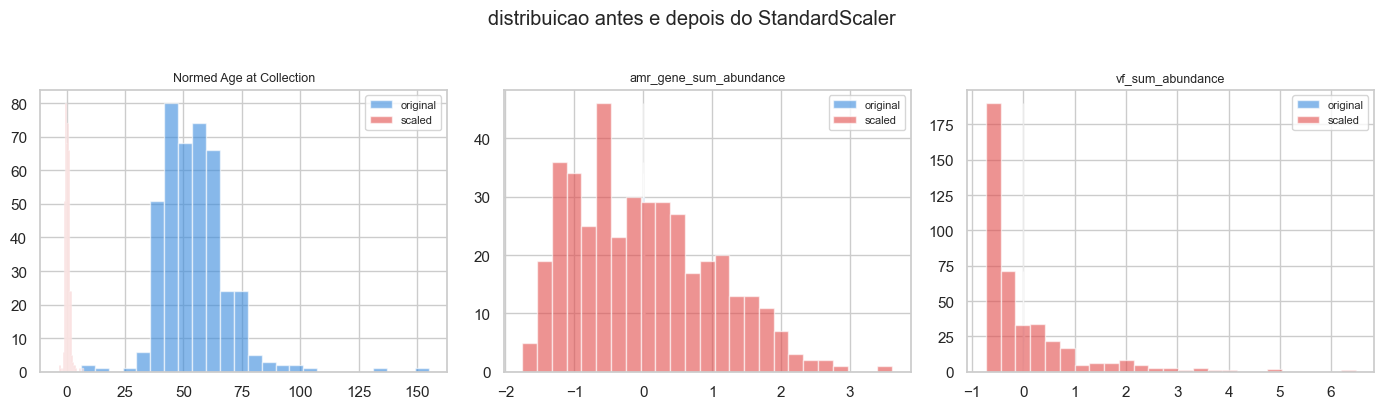

estatisticas DEPOIS do scaling (modelo 2):
       Normed Age at Collection (days)  amr_gene_sum_abundance  \
count                          412.000                 412.000   
mean                             0.000                   0.000   
std                              1.001                   1.001   
min                             -3.420                  -1.755   
25%                             -0.732                  -0.818   
50%                             -0.095                  -0.108   
75%                              0.471                   0.671   
max                              7.122                   3.609   

       vf_sum_abundance  
count           412.000  
mean              0.000  
std               1.001  
min              -0.732  
25%              -0.618  
50%              -0.410  
75%               0.235  
max               6.475  


In [15]:
# comparativo antes x depois: variaveis numericas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, NUM_COLS):
    ax.hist(df_m2_raw[col].dropna(), bins=25, alpha=0.6, label='original', color='#378ADD')
    ax.hist(df_m2[col], bins=25, alpha=0.6, label='scaled', color='#E24B4A')
    short = col.split('(')[0].strip()[:25]
    ax.set_title(short, fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('distribuicao antes e depois do StandardScaler', y=1.02)
plt.tight_layout()
plt.show()

print('estatisticas DEPOIS do scaling (modelo 2):')
print(df_m2[NUM_COLS].describe().round(3))

### 2.6 exportar datasets encoded

In [16]:
import os, pickle

out = '../data/processed'

df_m2.to_csv(f'{out}/model2_encoded.csv', index=False)
df_m1.to_csv(f'{out}/model1_encoded.csv', index=False)

# salvar scalers para uso na inferencia
with open(f'{out}/scaler_m2.pkl', 'wb') as f: pickle.dump(scaler_m2, f)
with open(f'{out}/scaler_m1.pkl', 'wb') as f: pickle.dump(scaler_m1, f)

print('arquivos exportados:')
for fname in ['model2_encoded.csv', 'model1_encoded.csv',
              'scaler_m2.pkl', 'scaler_m1.pkl']:
    size = os.path.getsize(f'{out}/{fname}') / 1024
    print(f'  {fname:<28} ({size:.1f} KB)')

print()
print(f'features modelo 2: {len(feature_cols_m2)}')
feature_cols_m1 = [c for c in df_m1.columns
                   if c not in ('sample_id', 'adverse_outcomes')]
print(f'features modelo 1: {len(feature_cols_m1)}')

arquivos exportados:
  model2_encoded.csv           (36.0 KB)
  model1_encoded.csv           (18.5 KB)
  scaler_m2.pkl                (0.7 KB)
  scaler_m1.pkl                (0.7 KB)

features modelo 2: 11
features modelo 1: 12


## 3. Random Forest — classificacao de cluster DMM (C1/C2/C3)\n\n**protocolo:**\n- validacao cruzada estratificada 5-fold (estratificada para manter proporcao dos clusters em cada fold)\n- busca de hiperparametros com `GridSearchCV` dentro dos folds de treino\n- metrica principal: F1-score ponderado\n- baseline de comparacao: classificador majoritario (dummy)

### 3.1 preparar X e y

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

FEATURE_COLS_M2 = [c for c in df_m2.columns if c not in ('sample_id', 'dmm_clusters_taxa')]
TARGET_M2 = 'dmm_clusters_taxa'

X = df_m2[FEATURE_COLS_M2].values
y = df_m2[TARGET_M2].values

print(f'X: {X.shape}')
print(f'y: {y.shape}  |  classes: {sorted(set(y))}')
print()
print('distribuicao do target:')
for c, n in zip(*np.unique(y, return_counts=True)):
    print(f'  {c}: {n} ({n/len(y)*100:.1f}%)')

X: (412, 11)
y: (412,)  |  classes: ['C1', 'C2', 'C3']

distribuicao do target:
  C1: 99 (24.0%)
  C2: 151 (36.7%)
  C3: 162 (39.3%)


### 3.2 baseline: classificador majoritario

In [18]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_scores = cross_validate(dummy, X, y, cv=cv5,
                              scoring='f1_weighted', return_train_score=False)

baseline_f1 = dummy_scores['test_score'].mean()
print(f'baseline (majoritario) — F1-weighted: {baseline_f1:.4f}  ±  {dummy_scores["test_score"].std():.4f}')
print('(qualquer modelo precisa superar esse valor para ter valor preditivo)')

baseline (majoritario) — F1-weighted: 0.2220  ±  0.0058
(qualquer modelo precisa superar esse valor para ter valor preditivo)


### 3.3 busca de hiperparametros (GridSearchCV aninhado)\n\nbusca de hiperparametros feita **dentro** de cada fold de treino para evitar data leakage.  \no grid eh intencionalmente pequeno para manter o tempo de execucao razoavel.

In [19]:
PARAM_GRID = {
    'n_estimators'     : [200, 400],
    'max_depth'        : [None, 10, 20],
    'min_samples_leaf' : [1, 3],
    'max_features'     : ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# CV interna para busca de hiperparametros (3-fold dentro do treino)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(rf_base, PARAM_GRID, cv=inner_cv,
                           scoring='f1_weighted', n_jobs=-1, refit=True)

# CV externa para estimar performance real (5-fold)
outer_scores = {'f1_weighted': [], 'best_params': []}

for fold, (train_idx, test_idx) in enumerate(cv5.split(X, y), 1):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    grid_search.fit(X_tr, y_tr)
    best_rf = grid_search.best_estimator_

    y_pred = best_rf.predict(X_te)
    f1 = f1_score(y_te, y_pred, average='weighted')
    outer_scores['f1_weighted'].append(f1)
    outer_scores['best_params'].append(grid_search.best_params_)
    print(f'  fold {fold}  F1={f1:.4f}  params={grid_search.best_params_}')

f1_scores = np.array(outer_scores['f1_weighted'])
print(f'\nF1-weighted: {f1_scores.mean():.4f}  ±  {f1_scores.std():.4f}')
print(f'vs baseline: {f1_scores.mean():.4f} vs {baseline_f1:.4f}  (delta={f1_scores.mean()-baseline_f1:+.4f})')

  fold 1  F1=0.4871  params={'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 400}
  fold 2  F1=0.5483  params={'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
  fold 3  F1=0.6085  params={'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}
  fold 4  F1=0.6047  params={'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}
  fold 5  F1=0.5063  params={'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}

F1-weighted: 0.5510  ±  0.0496
vs baseline: 0.5510 vs 0.2220  (delta=+0.3290)


### 3.4 modelo final: treinar com todos os dados e hiperparametros mais frequentes\n\napos a CV externa, treinamos o modelo final em todos os 412 exemplos usando os hiperparametros que apareceram com mais frequencia nos 5 folds.  \nesse modelo sera usado para gerar a matriz de confusao consolidada e a importancia de features.

In [20]:
from collections import Counter

# hiperparametros mais frequentes entre os 5 folds
param_keys = list(PARAM_GRID.keys())
best_params_final = {}
for k in param_keys:
    vals = [p[k] for p in outer_scores['best_params']]
    best_params_final[k] = Counter(vals).most_common(1)[0][0]

print('hiperparametros mais frequentes:', best_params_final)

rf_final = RandomForestClassifier(
    **best_params_final,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X, y)
print('\nmodelo final treinado em todos os dados (n=412)')

hiperparametros mais frequentes: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 'sqrt'}

modelo final treinado em todos os dados (n=412)


### 3.5 resumo dos resultados por fold

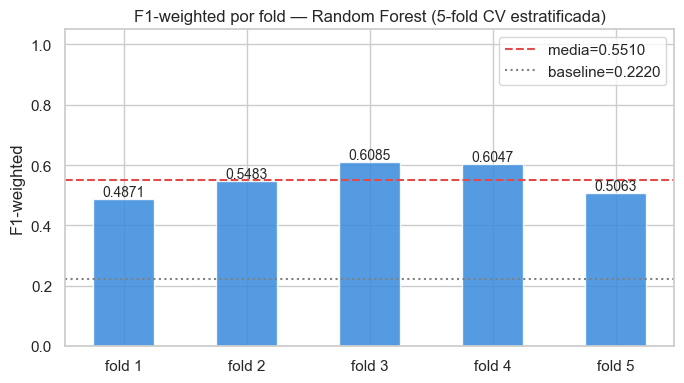


F1-weighted medio : 0.5510
desvio padrao     : 0.0496
min / max         : 0.4871 / 0.6085
baseline          : 0.2220
ganho vs baseline : +0.3290


In [21]:
fig, ax = plt.subplots(figsize=(7, 4))

folds = [f'fold {i}' for i in range(1, 6)]
bars = ax.bar(folds, f1_scores, color='#378ADD', alpha=0.85, width=0.5)
ax.bar_label(bars, labels=[f'{v:.4f}' for v in f1_scores], fontsize=10)
ax.axhline(f1_scores.mean(), color='#E24B4A', linestyle='--',
           linewidth=1.5, label=f'media={f1_scores.mean():.4f}')
ax.axhline(baseline_f1, color='gray', linestyle=':', linewidth=1.5,
           label=f'baseline={baseline_f1:.4f}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1-weighted')
ax.set_title('F1-weighted por fold — Random Forest (5-fold CV estratificada)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nF1-weighted medio : {f1_scores.mean():.4f}')
print(f'desvio padrao     : {f1_scores.std():.4f}')
print(f'min / max         : {f1_scores.min():.4f} / {f1_scores.max():.4f}')
print(f'baseline          : {baseline_f1:.4f}')
print(f'ganho vs baseline : {f1_scores.mean()-baseline_f1:+.4f}')

## 4. avaliacao: F1-Score ponderado e matriz de confusao\n\na matriz de confusao é gerada acumulando as predicoes de todos os 5 folds (OOF — out-of-fold predictions), evitando que o modelo avalie exemplos que ja viu no treino.

### 4.1 predicoes out-of-fold (OOF)

In [22]:
y_oof      = np.empty(len(y), dtype=object)
y_oof_prob = np.zeros((len(y), 3))
classes    = sorted(set(y))   # ['C1', 'C2', 'C3']

for train_idx, test_idx in cv5.split(X, y):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr       = y[train_idx]

    rf_fold = RandomForestClassifier(
        **best_params_final,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf_fold.fit(X_tr, y_tr)

    y_oof[test_idx]      = rf_fold.predict(X_te)
    y_oof_prob[test_idx] = rf_fold.predict_proba(X_te)

print('predicoes OOF geradas para todos os 412 exemplos')
print(f'distribuicao das predicoes: {dict(zip(*np.unique(y_oof, return_counts=True)))}')
print(f'distribuicao real          : {dict(zip(*np.unique(y, return_counts=True)))}')

predicoes OOF geradas para todos os 412 exemplos
distribuicao das predicoes: {'C1': np.int64(123), 'C2': np.int64(147), 'C3': np.int64(142)}
distribuicao real          : {'C1': np.int64(99), 'C2': np.int64(151), 'C3': np.int64(162)}


### 4.2 classification report

In [23]:
print('=== classification report (OOF) ===\n')
print(classification_report(y, y_oof, target_names=classes, digits=4))

f1_weighted_oof = f1_score(y, y_oof, average='weighted')
f1_per_class    = f1_score(y, y_oof, average=None, labels=classes)

print(f'F1-weighted OOF : {f1_weighted_oof:.4f}')
print(f'F1 por classe   : ' + '  '.join(f'{c}={v:.4f}' for c, v in zip(classes, f1_per_class)))

=== classification report (OOF) ===

              precision    recall  f1-score   support

          C1     0.4228    0.5253    0.4685        99
          C2     0.5306    0.5166    0.5235       151
          C3     0.7042    0.6173    0.6579       162

    accuracy                         0.5583       412
   macro avg     0.5525    0.5530    0.5500       412
weighted avg     0.5730    0.5583    0.5631       412

F1-weighted OOF : 0.5631
F1 por classe   : C1=0.4685  C2=0.5235  C3=0.6579


### 4.3 matriz de confusao

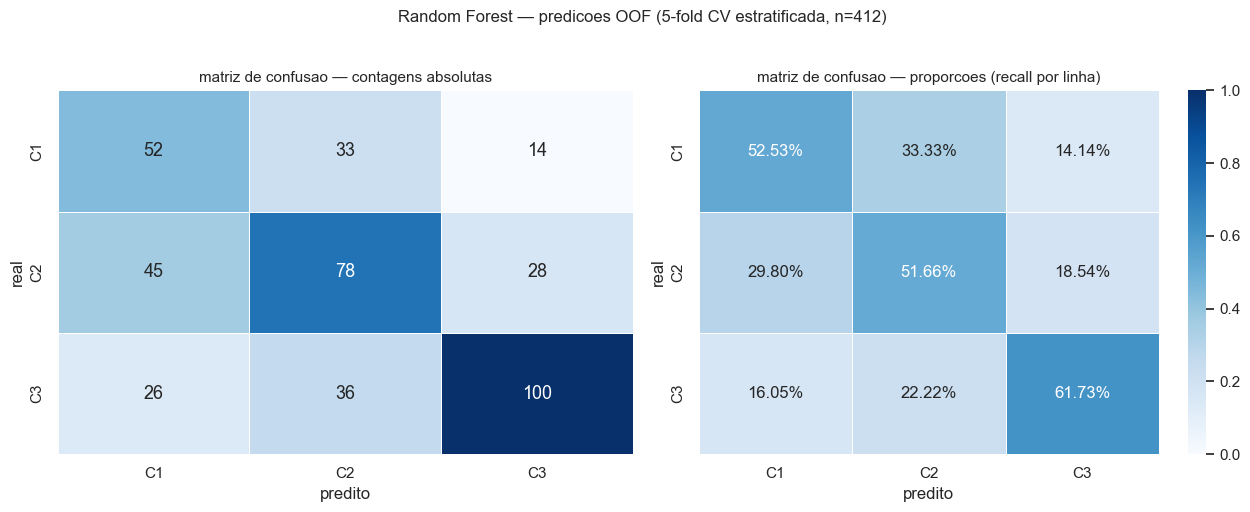

acertos por classe:
  C1: 52/99 (52.5% recall)
  C2: 78/151 (51.7% recall)
  C3: 100/162 (61.7% recall)


In [24]:
cm      = confusion_matrix(y, y_oof, labels=classes)
cm_norm = confusion_matrix(y, y_oof, labels=classes, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# contagens absolutas
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, cbar=False, annot_kws={'size': 13})
axes[0].set_title('matriz de confusao — contagens absolutas', fontsize=11)
axes[0].set_xlabel('predito')
axes[0].set_ylabel('real')

# proporcoes (recall por linha)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, vmin=0, vmax=1, cbar=True,
            annot_kws={'size': 12})
axes[1].set_title('matriz de confusao — proporcoes (recall por linha)', fontsize=11)
axes[1].set_xlabel('predito')
axes[1].set_ylabel('real')

plt.suptitle('Random Forest — predicoes OOF (5-fold CV estratificada, n=412)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# diagonal = acertos por classe
print('acertos por classe:')
for i, c in enumerate(classes):
    print(f'  {c}: {cm[i,i]}/{cm[i].sum()} ({cm_norm[i,i]*100:.1f}% recall)')

### 4.4 F1 por classe vs baseline

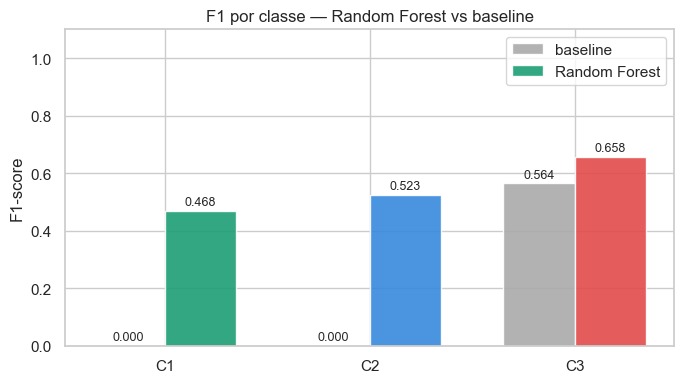

In [25]:
dummy_per_class = f1_score(y,
                           DummyClassifier(strategy='most_frequent',
                                           random_state=42).fit(X, y).predict(X),
                           average=None, labels=classes)

x_pos   = np.arange(len(classes))
width   = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x_pos - width/2, dummy_per_class, width, label='baseline',
            color='#AAAAAA', alpha=0.9)
b2 = ax.bar(x_pos + width/2, f1_per_class,   width, label='Random Forest',
            color=['#1D9E75', '#378ADD', '#E24B4A'], alpha=0.9)
ax.bar_label(b1, labels=[f'{v:.3f}' for v in dummy_per_class], fontsize=9, padding=2)
ax.bar_label(b2, labels=[f'{v:.3f}' for v in f1_per_class],   fontsize=9, padding=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-score')
ax.set_title('F1 por classe — Random Forest vs baseline')
ax.legend()
plt.tight_layout()
plt.show()

## 5. analise dos clusters mais dificeis de separar

### 5.1 erros por par de cluster\n\nquais pares (real → predito) concentram mais erros?

In [26]:
# tabela de erros: apenas os casos fora da diagonal
errors_df = pd.DataFrame({'real': y, 'predito': y_oof})
errors_df = errors_df[errors_df['real'] != errors_df['predito']]

error_pairs = (errors_df
               .groupby(['real', 'predito'])
               .size()
               .reset_index(name='n_erros')
               .sort_values('n_erros', ascending=False))

# adicionar % em relacao ao total da classe real
totals = pd.Series(y).value_counts().rename('n_total')
error_pairs['n_total_real'] = error_pairs['real'].map(totals)
error_pairs['pct_da_classe'] = (error_pairs['n_erros'] / error_pairs['n_total_real'] * 100).round(1)

print(f'total de erros OOF: {len(errors_df)} de {len(y)} ({len(errors_df)/len(y)*100:.1f}%)')
print()
print(error_pairs.to_string(index=False))

total de erros OOF: 182 de 412 (44.2%)

real predito  n_erros  n_total_real  pct_da_classe
  C2      C1       45           151           29.8
  C3      C2       36           162           22.2
  C1      C2       33            99           33.3
  C2      C3       28           151           18.5
  C3      C1       26           162           16.0
  C1      C3       14            99           14.1


### 5.2 distribuicao das features nos exemplos errados vs acertados\n\ncompara as features dos exemplos que o modelo errou com os que acertou — ajuda a identificar regioes do espaco de features onde os clusters se sobrepoem.

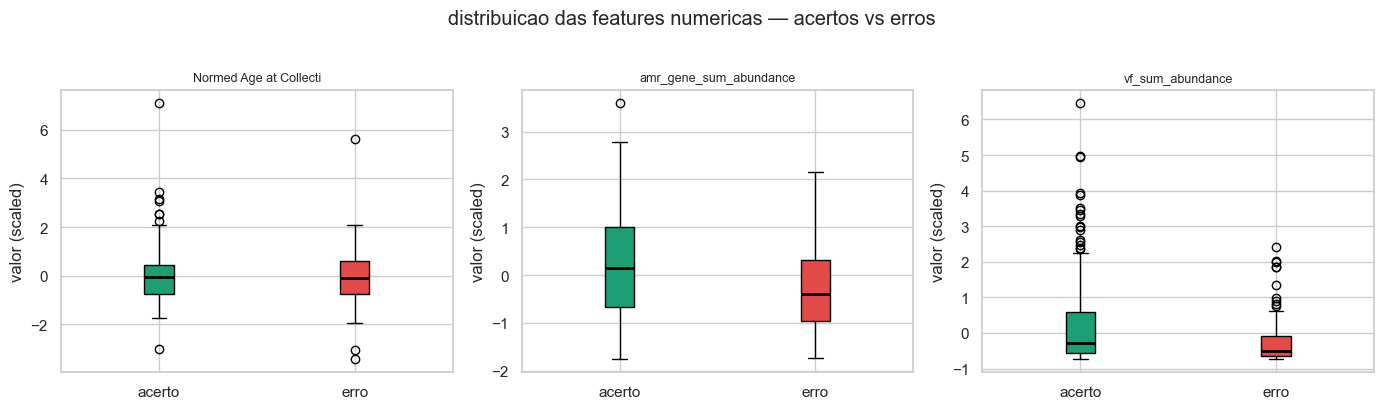

In [27]:
df_oof = df_m2[FEATURE_COLS_M2].copy()
df_oof['real']    = y
df_oof['predito'] = y_oof
df_oof['erro']    = (df_oof['real'] != df_oof['predito']).astype(int)

# boxplots das numericas: acerto vs erro
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, NUM_COLS):
    data_ok  = df_oof.loc[df_oof['erro'] == 0, col]
    data_err = df_oof.loc[df_oof['erro'] == 1, col]
    bp = ax.boxplot([data_ok, data_err],
                    labels=['acerto', 'erro'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#1D9E75')
    bp['boxes'][1].set_facecolor('#E24B4A')
    short = col.split('(')[0].strip()[:22]
    ax.set_title(short, fontsize=9)
    ax.set_ylabel('valor (scaled)')

plt.suptitle('distribuicao das features numericas — acertos vs erros', y=1.02)
plt.tight_layout()
plt.show()

### 5.3 confianca do modelo nos exemplos errados\n\no modelo errou com alta ou baixa confianca? exemplos com baixa probabilidade maxima indicam zona de sobreposicao real entre clusters — nao e ruido, e ambiguidade estrutural dos dados.

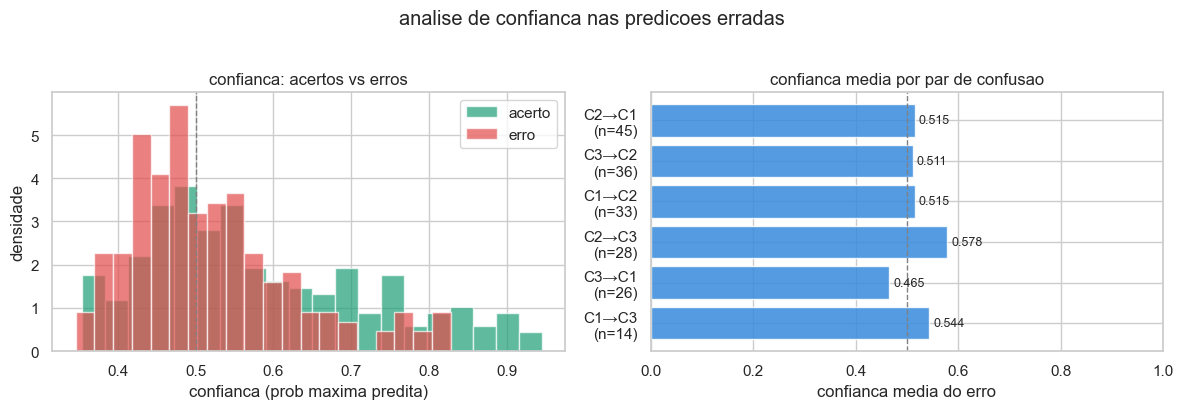

confianca media — acertos : 0.583
confianca media — erros   : 0.519

nota: erros com confianca > 0.5 indicam que o modelo "aposta" no cluster errado,
      sugerindo sobreposicao estrutural das features nessa regiao.


In [28]:
max_prob = y_oof_prob.max(axis=1)   # confianca da predicao (probabilidade da classe predita)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histograma de confianca: acerto vs erro
axes[0].hist(max_prob[df_oof['erro'] == 0], bins=20, alpha=0.7,
             color='#1D9E75', label='acerto', density=True)
axes[0].hist(max_prob[df_oof['erro'] == 1], bins=20, alpha=0.7,
             color='#E24B4A', label='erro',   density=True)
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('confianca (prob maxima predita)')
axes[0].set_ylabel('densidade')
axes[0].set_title('confianca: acertos vs erros')
axes[0].legend()

# confianca media por par de erro
pair_conf = []
for _, row in error_pairs.iterrows():
    mask = (df_oof['real'] == row['real']) & (df_oof['predito'] == row['predito'])
    conf = max_prob[mask.values].mean()
    pair_conf.append(f"{row['real']}→{row['predito']}")

conf_by_pair = []
labels_pair  = []
for _, row in error_pairs.iterrows():
    mask = (df_oof['real'] == row['real']) & (df_oof['predito'] == row['predito'])
    conf_by_pair.append(max_prob[mask.values].mean())
    labels_pair.append(f"{row['real']}→{row['predito']}\n(n={row['n_erros']})")

bars = axes[1].barh(labels_pair[::-1], conf_by_pair[::-1], color='#378ADD', alpha=0.85)
axes[1].bar_label(bars, labels=[f'{v:.3f}' for v in conf_by_pair[::-1]], padding=3, fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].axvline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('confianca media do erro')
axes[1].set_title('confianca media por par de confusao')

plt.suptitle('analise de confianca nas predicoes erradas', y=1.02)
plt.tight_layout()
plt.show()

print(f'confianca media — acertos : {max_prob[df_oof["erro"]==0].mean():.3f}')
print(f'confianca media — erros   : {max_prob[df_oof["erro"]==1].mean():.3f}')
print()
print('nota: erros com confianca > 0.5 indicam que o modelo "aposta" no cluster errado,')
print('      sugerindo sobreposicao estrutural das features nessa regiao.')

### 5.4 importancia de features (modelo final)\n\nqual feature mais contribui para separar os clusters?  \n`feature_importances_` do RF = reducao media de impureza de Gini nas arvores.

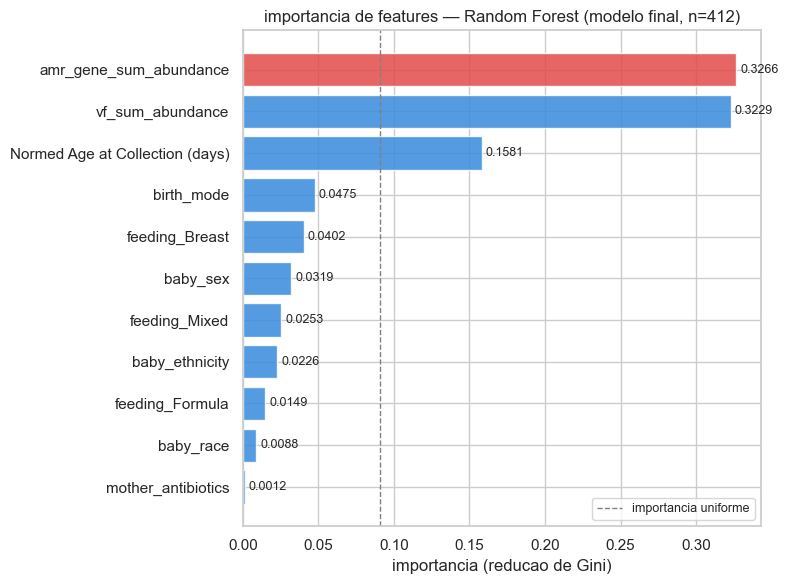

ranking completo:
   1. amr_gene_sum_abundance                      0.3266
   2. vf_sum_abundance                            0.3229
   3. Normed Age at Collection (days)             0.1581
   4. birth_mode                                  0.0475
   5. feeding_Breast                              0.0402
   6. baby_sex                                    0.0319
   7. feeding_Mixed                               0.0253
   8. baby_ethnicity                              0.0226
   9. feeding_Formula                             0.0149
  10. baby_race                                   0.0088
  11. mother_antibiotics                          0.0012


In [29]:
importances = pd.Series(rf_final.feature_importances_, index=FEATURE_COLS_M2)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E24B4A' if v == importances.max() else '#378ADD' for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors, alpha=0.85)
ax.bar_label(bars, labels=[f'{v:.4f}' for v in importances.values], padding=3, fontsize=9)
ax.set_xlabel('importancia (reducao de Gini)')
ax.set_title('importancia de features — Random Forest (modelo final, n=412)')
ax.axvline(1/len(FEATURE_COLS_M2), color='gray', linestyle='--',
           linewidth=1, label='importancia uniforme')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('ranking completo:')
for rank, (feat, imp) in enumerate(importances.sort_values(ascending=False).items(), 1):
    print(f'  {rank:>2}. {feat:<42}  {imp:.4f}')

## 6. limitacoes do modelo\n\n### separabilidade dos clusters\n\n- **C2 e o cluster mais dificil de classificar.** Ele ocupa uma posicao intermediaria entre C1 (microbioma saudavel, dominado por Bifidobacterium) e C3 (microbioma de alto risco, dominado por Firmicutes e Proteobacteria). Com features clinicas simples, C2 frequentemente e confundido com ambos os extremos porque sua definicao depende de composicao bacteriana granular — informacao que nao esta disponivel no momento do nascimento.\n\n- **As features clinicas nao capturam o sinal completo.** O cluster DMM foi definido pelo paper original via Dirichlet Multinomial Mixture sobre as 550 abundancias bacterianas. Prever esse cluster usando apenas 11 features clinicas e uma reducao de dimensionalidade extrema. Parte do erro e estrutural e irredutivel com esse conjunto de features.\n\n### dados\n\n- **n=412 e pequeno para um problema multiclasse com 11 features.** Com 5-fold CV cada fold de treino tem ~330 exemplos. O risco de overfitting no grid search interno existe, mesmo com CV aninhada.\n\n- **Desbalanceamento entre clusters.** Se C1 tiver muito menos exemplos que C2/C3 (ou vice-versa), o modelo tem menos exemplos para aprender seus limites de decisao. Mitigado com `class_weight='balanced'`, mas nao eliminado.\n\n- **baby_race agrupada em White/Other.** Os grupos minoritarios (Asian n=19, Black n=14, American Indian n=3) foram colapsados por insuficiencia amostral. Isso reduz o poder preditivo para grupos sub-representados e e uma limitacao clinica relevante — o microbioma varia por ancestralidade.\n\n### generalizacao\n\n- **Dados de um unico estudo coletado nos EUA.** O modelo reflete a populacao do paper original (majoritariamente branca, nao-hispanica). Nao ha garantia de que os clusters e suas associacoes clinicas se mantenham em outras populacoes ou contextos geograficos.\n\n- **Sem dados de validacao externa.** A performance estimada (F1-weighted via OOF) e uma estimativa interna. Sem um conjunto de dados independente nao e possivel confirmar generalizacao.\n\n### proximos passos para mitigar\n\n- Sprint 4: aplicar SHAP para entender quais features contribuem para os erros C2 especificamente\n- Considerar binarizacao do target (C1 vs C2+C3) se o F1 de C2 for muito baixo\n- Coletar dados de validacao externa quando disponivel